# Customer Churn Prediction in Banking: A Comparative Machine Learning Approach

## 1. Problem Statement

Customer churn represents a major challenge for financial institutions, as retaining existing customers is generally more cost-effective than acquiring new customers. High churn rates can lead to revenue loss, reduced customer lifetime value, and increased marketing expenditure.

The objective of this project is to investigate how machine learning models can be used to predict customer churn in the banking sector while balancing predictive performance and model interpretability. The study compares multiple classification techniques to identify key churn drivers and assess how predictive analytics can support customer retention strategies.

The study evaluates customer churn prediction using a publicly available banking dataset containing demographic, financial, and behavioural customer information. Multiple machine learning models are compared to assess predictive performance and model interpretability.

---

## 2. Research Question

**How do different machine learning classification models compare in balancing predictive accuracy and interpretability for customer churn prediction in the banking sector?**

### Sub-Questions

1. Which customer characteristics are most strongly associated with churn?

2. Do more complex machine learning models outperform simpler and more interpretable models?

3. What are the trade-offs between predictive performance and model interpretability in churn prediction?

4. What actionable retention strategies can be derived from churn prediction models?

---

## 3. Objectives

The objectives of this study are:

* To identify key customer attributes associated with churn
* To perform exploratory data analysis to detect churn patterns
* To compare classification models for churn prediction
* To evaluate model performance using multiple metrics
* To assess model explainability and business applicability
* To generate actionable customer retention recommendations

# 4. Importing Libraries and Setting Up the Environment

This section imports the required Python libraries used for data manipulation, visualization, machine learning, and model evaluation.

The selected libraries support:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Machine learning model development
- Performance evaluation and interpretation

The analysis follows a structured workflow beginning with data preparation, followed by exploratory analysis, predictive modelling, and business interpretation.

In [ ]:

# Core Libraries

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('default')
sns.set_theme(style="whitegrid")


# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handling Class Imbalance
from sklearn.utils.class_weight import compute_class_weight

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 5. Data Loading and Initial Inspection

Before preprocessing and modelling, the datasets are loaded and inspected to understand their structure, variables, and overall quality.

The initial inspection includes:

- Dataset dimensions
- Variable names and data types
- Missing values
- Duplicate records
- Initial churn distribution

This step helps identify potential data quality issues and informs preprocessing decisions in later stages of the analysis.

In [ ]:

# Load Dataset

primary_df = pd.read_csv("Churn_Modelling.csv")


# Basic Information

print("Dataset Shape:", primary_df.shape)

print("\nColumn Names:")
print(primary_df.columns.tolist())

print("\nFirst 5 Rows:")
display(primary_df.head())

Dataset Shape: (10000, 14)

Column Names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 6. Initial Data Inspection

Before preprocessing, an initial inspection of the dataset is conducted to evaluate its structure, completeness, and overall quality.

This stage includes:

- Data types and variable structure
- Missing value analysis
- Duplicate record detection
- Descriptive statistics
- Churn distribution assessment

These checks help identify potential issues that may affect model performance and guide preprocessing decisions.

In [ ]:
print("DATASET INFORMATION")
primary_df.info()

print("\nMissing Values")
print(primary_df.isnull().sum())

print("\nDuplicate Records")
print(primary_df.duplicated().sum())

print("\nDescriptive Statistics")
display(primary_df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing Values
RowNumber          0
CustomerId         0
Surname         

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


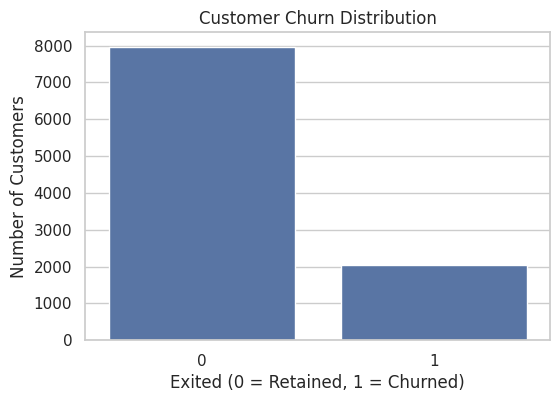

In [ ]:
churn_counts = primary_df['Exited'].value_counts()

print(churn_counts)

print("\nChurn Percentage:")
print(primary_df['Exited'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=primary_df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()


# 7. Data Cleaning and Feature Selection

Before modelling, irrelevant variables that do not contribute meaningful predictive information are removed.

Variables such as customer identifiers and surnames do not provide behavioural or financial insights relevant to churn prediction. Including such variables may introduce unnecessary noise and reduce model interpretability.

The following variables are removed:

- `RowNumber`
- `CustomerId`
- `Surname`

In [ ]:
primary_df = primary_df.drop(
    columns=['RowNumber', 'CustomerId', 'Surname']
)

primary_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 8. Encoding Categorical Variables

Machine learning algorithms require numerical inputs and cannot directly process categorical text variables.

Two categorical variables were identified:

- `Gender`
- `Geography`

`Gender` was binary encoded, while `Geography` was transformed using one-hot encoding to avoid introducing artificial ordinal relationships between categories.

One category was excluded during encoding to avoid multicollinearity (dummy variable trap).

In [ ]:
primary_df['Geography_Germany'] = (
    primary_df['Geography_Germany']
    .astype(int)
)

primary_df['Geography_Spain'] = (
    primary_df['Geography_Spain']
    .astype(int)
)

primary_df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


# 9. Outlier Inspection

Outlier analysis is conducted to identify extreme observations that may influence model performance.

In financial datasets, extreme values do not necessarily indicate errors, as high balances or salaries may reflect genuine customer characteristics. Therefore, outliers are examined carefully before any treatment decision is made.

Boxplots are used to visually inspect the distribution of numerical variables.

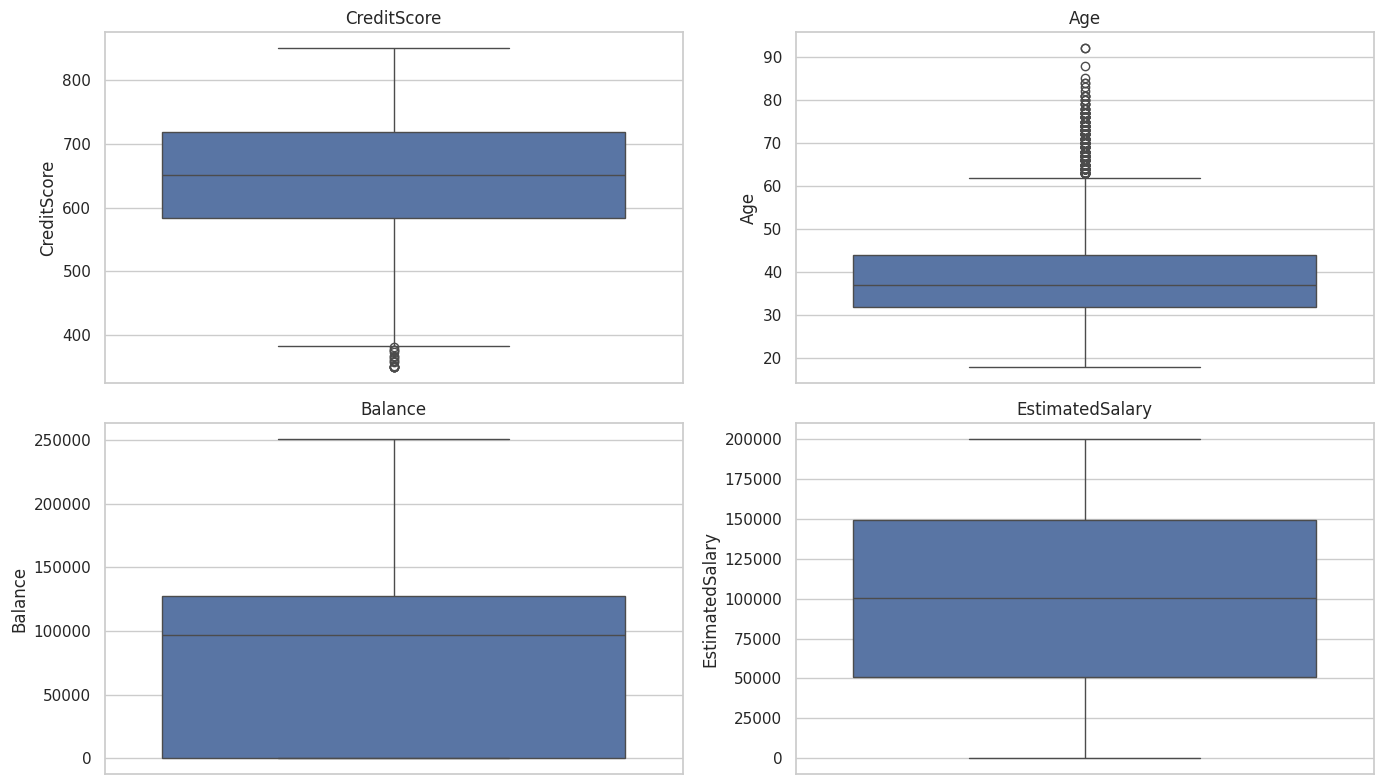

In [ ]:
numerical_columns = [
    'CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary'
]

plt.figure(figsize=(14,8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=primary_df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# 10. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to identify customer characteristics associated with churn.

The analysis focuses on:

- Overall churn distribution
- Demographic characteristics
- Financial variables
- Customer activity indicators
- Geographic patterns

The objective is to identify potential churn drivers and generate business insights prior to predictive modelling.

## churn by gender

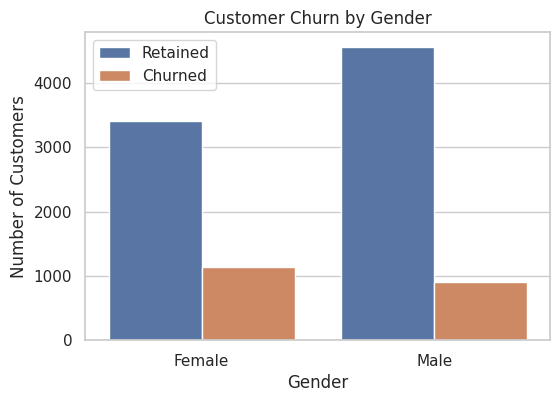

In [ ]:
primary_df['Gender_Label'] = primary_df['Gender'].map({
    0: 'Female',
    1: 'Male'
})

plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender_Label',
    hue='Exited',
    data=primary_df
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(['Retained', 'Churned'])

plt.show()

## churn by geography

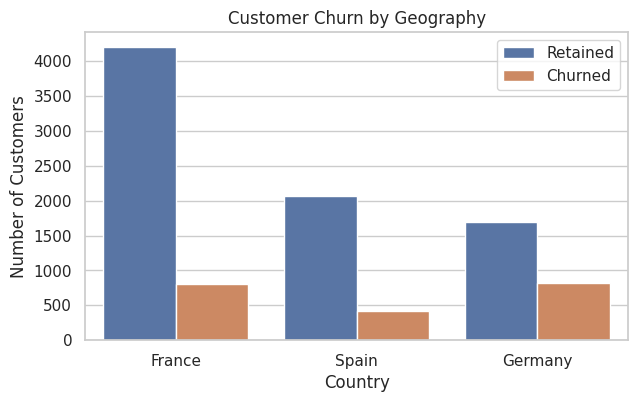

Exited,0,1
Geography_Label,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [ ]:
primary_df['Geography_Label'] = np.select(
    [
        primary_df['Geography_Germany'] == 1,
        primary_df['Geography_Spain'] == 1
    ],
    [
        'Germany',
        'Spain'
    ],
    default='France'
)

plt.figure(figsize=(7,4))

sns.countplot(
    x='Geography_Label',
    hue='Exited',
    data=primary_df
)

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(['Retained', 'Churned'])

plt.show()

geography_churn = pd.crosstab(
    primary_df['Geography_Label'],
    primary_df['Exited'],
    normalize='index'
) * 100

display(geography_churn)

## churn by age

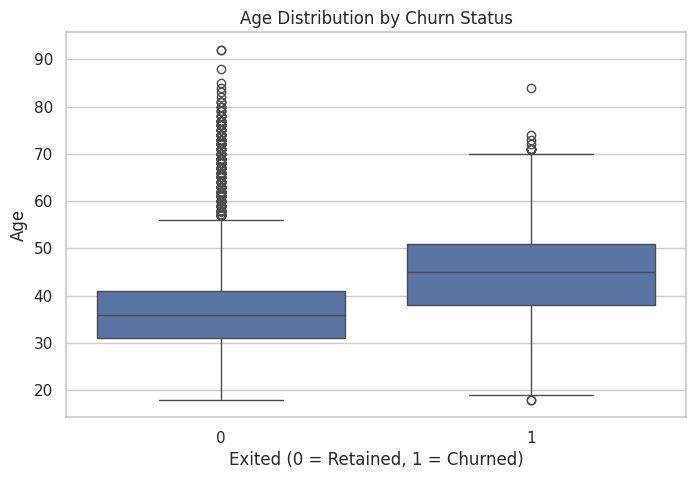

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=primary_df
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Age")

plt.show()

primary_df.groupby('Exited')['Age'].describe()

## Active Member Status

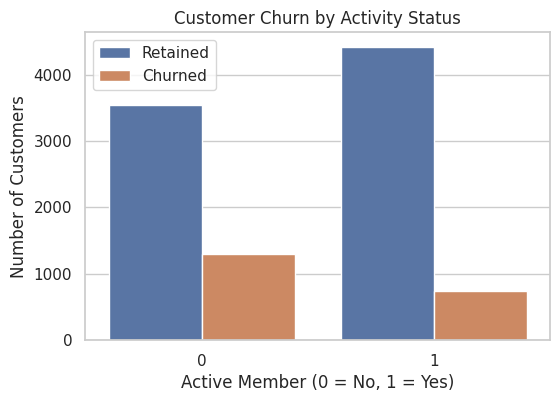

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=primary_df
)

plt.title("Customer Churn by Activity Status")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.legend(['Retained', 'Churned'])

plt.show()

activity_churn = pd.crosstab(
    primary_df['IsActiveMember'],
    primary_df['Exited'],
    normalize='index'
) * 100

display(activity_churn)

Correlation Heatmap

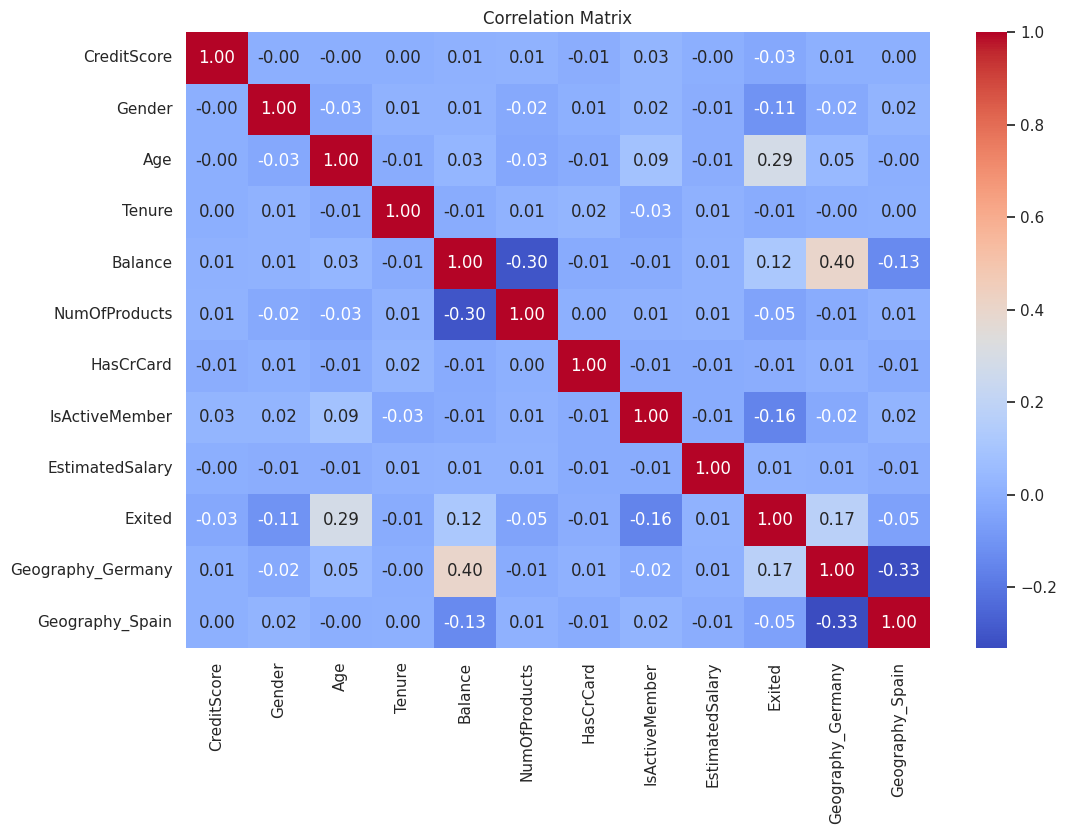

In [ ]:
plt.figure(figsize=(12,8))

correlation_matrix = primary_df.drop(
    columns=['Gender_Label', 'Geography_Label']
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

# 11. Data Preparation for Modelling

Before model implementation, the dataset is divided into training and testing subsets.

The target variable (`Exited`) is separated from predictor variables, and a stratified train-test split is applied to preserve the churn distribution across datasets.

Feature scaling is applied to numerical variables for models sensitive to variable magnitude, such as Logistic Regression.

In [ ]:
X = primary_df.drop(
    columns=[
        'Exited',
        'Gender_Label',
        'Geography_Label'
    ]
)

y = primary_df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (8000, 11)
Testing set shape: (2000, 11)

Training churn distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Testing churn distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


# 12. Feature Scaling

Feature scaling is applied to standardize numerical variables for models sensitive to variable magnitude.

Logistic Regression is particularly sensitive to differences in scale, therefore numerical features are standardized using z-score normalization.

Tree-based models such as Random Forest and Gradient Boosting do not require scaling and are therefore trained using unscaled features.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# 13. Logistic Regression Model (Baseline)

Logistic Regression is implemented as the baseline classification model.

As a relatively simple and interpretable model, Logistic Regression provides a useful benchmark for evaluating more advanced machine learning techniques.

The model estimates the probability of customer churn based on customer characteristics and enables interpretation of feature effects through model coefficients.

In [ ]:
log_model = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

log_model.fit(
    X_train_scaled,
    y_train
)

y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

Accuracy: 0.7135
Precision: 0.38722826086956524
Recall: 0.7002457002457002
F1 Score: 0.49868766404199477
ROC-AUC: 0.7771376923919298


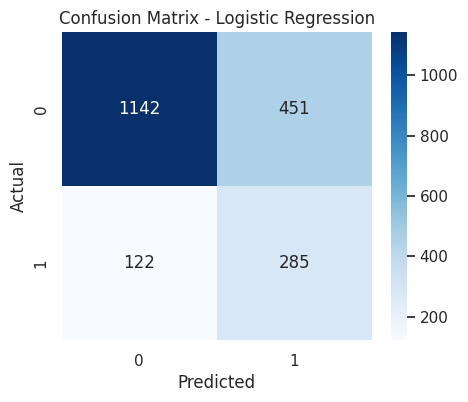

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(
    y_test,
    y_pred_log
))

# 14. Random Forest Model

Random Forest is implemented as a tree-based ensemble learning model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and complex interactions between variables. The model also provides feature importance measures, allowing interpretation of influential churn predictors.

The performance of Random Forest is compared against the Logistic Regression baseline.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.8625
Precision: 0.782051282051282
Recall: 0.44963144963144963
F1 Score: 0.5709828393135725
ROC-AUC: 0.8546728546728546


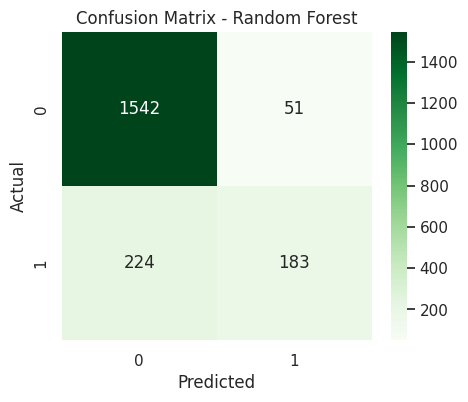

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(
    y_test,
    y_pred_rf
))

# 15. Random Forest Feature Importance

Feature importance analysis is conducted to identify the variables that contribute most strongly to churn prediction.

Understanding influential predictors helps improve model interpretability and supports evidence-based customer retention strategies.

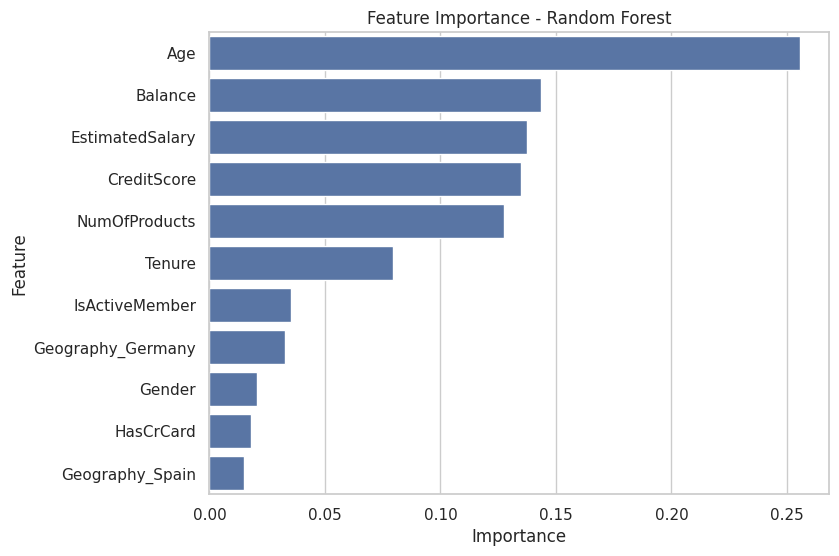

,Feature,Importance
2,Age,0.255595
4,Balance,0.143344
8,EstimatedSalary,0.137498
0,CreditScore,0.134865
5,NumOfProducts,0.127452
3,Tenure,0.079522
7,IsActiveMember,0.035532
9,Geography_Germany,0.032779
1,Gender,0.020483
6,HasCrCard,0.017883


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

display(feature_importance)

# 16. Gradient Boosting Model

Gradient Boosting is implemented as an advanced ensemble learning technique designed to improve predictive performance through sequential learning.

Unlike Random Forest, Gradient Boosting builds decision trees iteratively, where each new tree corrects errors made by previous trees. This enables the model to capture complex patterns in customer behaviour.

The model is evaluated and compared against Logistic Regression and Random Forest to assess trade-offs between predictive performance and interpretability.

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(
    X_test
)[:, 1]

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("Precision:",
      precision_score(y_test, y_pred_gb))

print("Recall:",
      recall_score(y_test, y_pred_gb))

print("F1 Score:",
      f1_score(y_test, y_pred_gb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.872
Precision: 0.7984189723320159
Recall: 0.4963144963144963
F1 Score: 0.6121212121212121
ROC-AUC: 0.8711839728788882


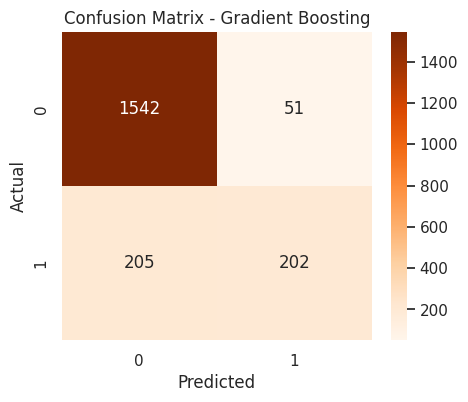

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_gb
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(classification_report(
    y_test,
    y_pred_gb
))

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.714,0.387,0.700,0.499,0.777
1,Random Forest,0.862,0.782,0.450,0.571,0.855
2,Gradient Boosting,0.872,0.798,0.496,0.612,0.871


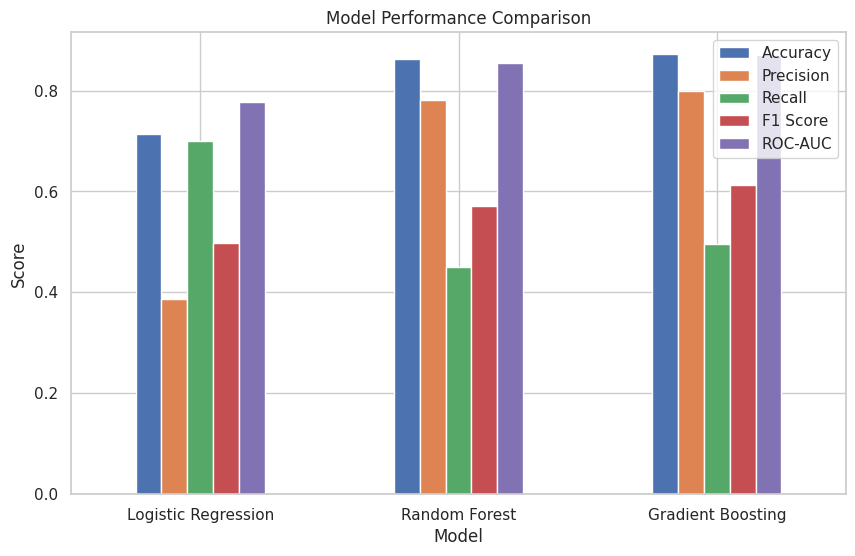

In [ ]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# 17. Logistic Regression Interpretation

Logistic Regression coefficients are analysed to improve model interpretability and identify variables associated with increased or decreased churn probability.

Positive coefficients indicate variables associated with higher churn likelihood, while negative coefficients indicate variables associated with customer retention.

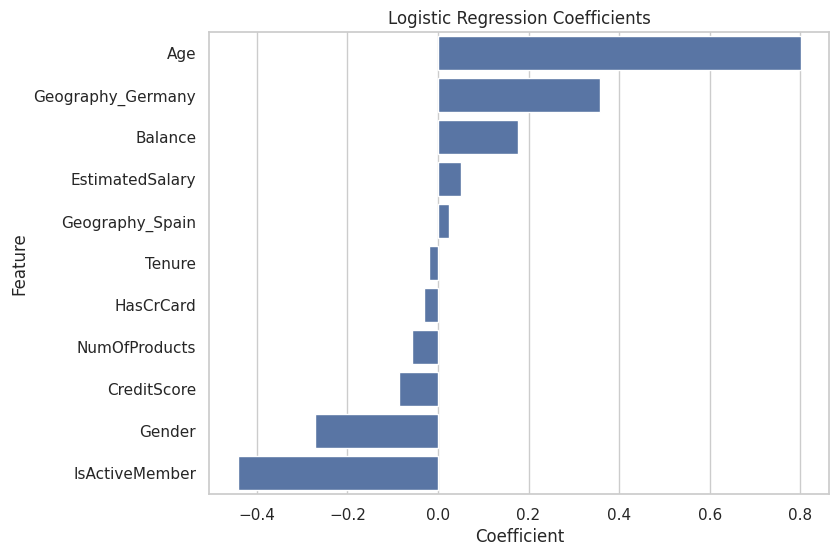

,Feature,Coefficient
2,Age,0.801883
9,Geography_Germany,0.357669
4,Balance,0.175751
8,EstimatedSalary,0.050502
10,Geography_Spain,0.023974
3,Tenure,-0.018831
6,HasCrCard,-0.031611
5,NumOfProducts,-0.057734
0,CreditScore,-0.087119
1,Gender,-0.272170


In [ ]:
log_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

log_coefficients = log_coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=log_coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title("Logistic Regression Coefficients")

plt.show()

display(log_coefficients)

# 18. Business Impact and Retention Recommendations

The findings from the predictive models can help banks improve customer retention strategies.

Customer churn creates financial losses because acquiring new customers is generally more expensive than retaining existing ones. Therefore, identifying high-risk customers can support more effective and targeted business decisions.

Based on the exploratory analysis and model findings, several retention strategies are proposed.

In [ ]:
high_risk_customers = primary_df[
    (
        primary_df['Age'] > 40
    ) &
    (
        primary_df['IsActiveMember'] == 0
    ) &
    (
        primary_df['Geography_Germany'] == 1
    )
]

print(
    "Number of High-Risk Customers:",
    len(high_risk_customers)
)

high_risk_customers.head()

Number of High-Risk Customers: 532


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Label,Geography_Label
16,653,1,58,1,132602.88,1,1,0,5097.67,1,1,0,Male,Germany
32,553,1,41,9,110112.54,2,0,0,81898.81,0,1,0,Male,Germany
50,698,1,44,10,116363.37,2,1,0,198059.16,0,1,0,Male,Germany
53,655,1,41,8,125561.97,1,0,0,164040.94,1,1,0,Male,Germany
54,601,1,42,1,98495.72,1,1,0,40014.76,1,1,0,Male,Germany


## Key Business Findings

The analysis identified several important customer groups with higher churn risk.

### High-Risk Customer Characteristics

Customers were more likely to churn when they had the following characteristics:

- Older age
- Inactive account status
- Located in Germany
- Higher account balances

These findings suggest that customer behaviour and engagement play an important role in retention.

### Recommended Retention Actions

Based on the findings, the following strategies may help reduce customer churn:

#### 1. Target inactive customers

Inactive customers showed a much higher churn rate. Banks could introduce loyalty campaigns, reminders, or personalised offers to improve engagement.

#### 2. Focus on customers in Germany

Customers in Germany had the highest churn rate. Region-specific customer service improvements or local marketing campaigns may improve retention.

#### 3. Protect high-value customers

Customers with higher balances appeared more likely to leave. Banks should prioritise premium support and personalised financial services for these customers.

#### 4. Early intervention for older customers

Older customers showed higher churn probability. Early engagement and customer relationship programs may reduce churn risk.

# 19. Model Comparison and Final Recommendation

Three machine learning models were evaluated for customer churn prediction.

Gradient Boosting achieved the strongest overall predictive performance, with the highest accuracy, F1-score, and ROC-AUC score.

However, Logistic Regression showed stronger recall performance and provided better interpretability through model coefficients.

Therefore, the choice of model depends on business objectives:

- If the goal is to identify as many churned customers as possible, Logistic Regression may be preferred.

- If the goal is stronger predictive performance, Gradient Boosting may be more suitable.

Overall, Gradient Boosting was selected as the best-performing model for this study because it achieved the strongest balance across multiple evaluation metrics.

# 20. Limitations of the Study

Although the study produced useful findings, several limitations should be considered.

### 1. Dataset limitations

The study uses publicly available banking churn data rather than real customer data from a financial institution. As a result, customer behaviour in real banking environments may be different.

### 2. Limited feature availability

The dataset includes demographic and financial information, but other important factors may also influence customer churn. For example, customer satisfaction, service quality, complaint history, and digital banking activity were not included.

### 3. Generalizability of findings

Although the dataset contains 10,000 customer records, it represents a publicly available dataset rather than real institutional banking data. Therefore, customer behaviour and churn patterns may differ in real-world banking environments.
### 4. Trade-off between performance and explainability

More complex models such as Gradient Boosting achieved stronger predictive performance but were more difficult to interpret. Simpler models such as Logistic Regression were easier to explain but achieved lower predictive accuracy.

### 5. Correlation does not imply causation

The findings show associations between customer characteristics and churn behaviour. However, this does not prove that these variables directly cause churn.

# 21. Recommendations for Future Research

Future studies could improve this research in several ways.

- Use larger and more diverse banking datasets
- Include behavioural customer data such as transaction activity or customer complaints
- Apply more advanced machine learning models such as XGBoost or neural networks
- Test model performance across multiple banking datasets
- Investigate explainable AI methods to improve model transparency

# 22. Cross-Validation

Cross-validation is used to evaluate the stability and reliability of model performance.

Instead of relying on one train-test split, the dataset is divided into several folds. The model is trained and tested multiple times using different subsets of data.

This helps reduce bias and provides a more reliable estimate of model performance.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
log_cv = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

gb_cv = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean ROC-AUC': [
        log_cv.mean(),
        rf_cv.mean(),
        gb_cv.mean()
    ],
    'Standard Deviation': [
        log_cv.std(),
        rf_cv.std(),
        gb_cv.std()
    ]
})

display(cv_results.round(3))

,Model,Mean ROC-AUC,Standard Deviation
0,Logistic Regression,0.767,0.012
1,Random Forest,0.858,0.010
2,Gradient Boosting,0.864,0.012


# 23. ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves are used to compare the predictive ability of the machine learning models.

The ROC curve evaluates how effectively a model distinguishes between churned and retained customers.

A larger Area Under the Curve (AUC) indicates better classification performance.

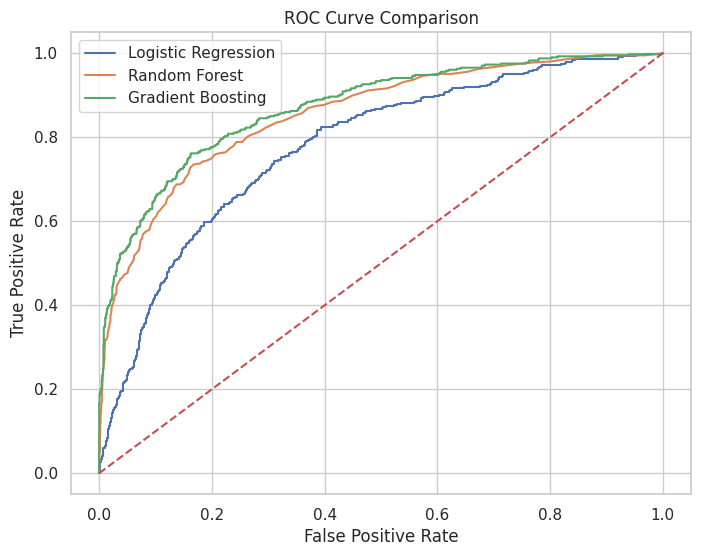

In [ ]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label='Gradient Boosting'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# 24. Model Selection Justification

The selected machine learning models were chosen based on differences in complexity and interpretability.

Logistic Regression was used as a baseline model because of its simplicity and strong interpretability. The model enables direct analysis of how customer characteristics influence churn probability.

Random Forest and Gradient Boosting were selected as advanced tree-based methods capable of identifying non-linear relationships and complex interactions between customer variables.

The comparison between simpler and more advanced models supports a balanced evaluation between predictive performance and model explainability.

# 25. Conclusion

This study examined customer churn prediction in the banking sector using machine learning techniques.

The analysis began with exploratory data analysis to identify important customer characteristics associated with churn. Several patterns were identified, including higher churn among older customers, inactive members, customers located in Germany, and customers with higher account balances.

Three machine learning models were implemented and compared: Logistic Regression, Random Forest, and Gradient Boosting.

The results showed differences in predictive performance between the models. Logistic Regression provided strong interpretability and achieved higher recall, meaning it was more effective at identifying churned customers. However, its overall predictive performance was lower compared to tree-based methods.

Random Forest improved classification performance and achieved higher accuracy and precision. However, the model showed lower recall, meaning some churned customers were missed.

Gradient Boosting achieved the strongest overall performance, producing the highest accuracy, F1-score, ROC-AUC score, and consistent results during cross-validation. Therefore, it was selected as the best-performing model in this study.

The findings also showed a trade-off between model interpretability and predictive performance. Simpler models such as Logistic Regression were easier to explain, while more advanced models achieved stronger prediction accuracy.

From a business perspective, the results suggest that banks may improve customer retention by focusing on inactive customers, high-balance customers, older customers, and customers in high-risk regions such as Germany.

Although the study produced useful findings, limitations remain. The analysis was based on a publicly available dataset and may not fully represent real banking environments. Future research may include larger datasets, behavioural customer data, and more advanced explainable AI methods.

Overall, this study demonstrates that machine learning can provide useful support for customer churn prediction and help financial institutions improve retention strategies and customer relationship management.